In [3]:
# =====================================================
# 🧩 1. Import and Load Data
# =====================================================
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load datasets
airports = pd.read_csv("data/airports.csv")
routes = pd.read_csv("data/routes.csv")

print("✅ Data loaded successfully")
print("Airports:", airports.shape)
print("Routes:", routes.shape)

# =====================================================
# 🧹 2. Clean and Prepare Data
# =====================================================

# Replace missing continent for U.S. airports with "NA"
airports.loc[airports["iso_country"] == "US", "continent"] = airports.loc[airports["iso_country"] == "US", "continent"].fillna("NA")

# Drop airports missing important info
airports = airports.dropna(subset=["id", "latitude_deg", "longitude_deg"])

# Clean route ID columns ('\\N' means missing)
routes["Source airport ID"] = routes["Source airport ID"].replace("\\N", pd.NA)
routes["Destination airport ID"] = routes["Destination airport ID"].replace("\\N", pd.NA)

# Drop missing IDs and convert to int
routes = routes.dropna(subset=["Source airport ID", "Destination airport ID"])
routes["Source airport ID"] = routes["Source airport ID"].astype(int)
routes["Destination airport ID"] = routes["Destination airport ID"].astype(int)
airports["id"] = airports["id"].astype(int)

print("✅ Data cleaned")

# =====================================================
# 🌍 3. Filter for NATO Countries
# =====================================================
nato_countries = [
    "US","CA","IS","NO","DK","NL","BE","LU","FR","DE","IT","PT",
    "UK","ES","GR","TR","PL","CZ","HU","SK","SI","HR","BG","RO",
    "EE","LV","LT","AL","ME","MK", "FI", "SE"
]

airports_nato = airports[airports["iso_country"].isin(nato_countries)].copy()
print("NATO airports:", len(airports_nato))

nato_ids = set(airports_nato["id"].astype(int))
routes_nato = routes[
    routes["Source airport ID"].isin(nato_ids) &
    routes["Destination airport ID"].isin(nato_ids)
].copy()
print("NATO routes:", len(routes_nato))

# =====================================================
# 💪 4. Add Edge Weights Based on Route Counts
# =====================================================

# Count number of routes (flights) between each airport pair
wdir = (routes_nato
        .groupby(["Source airport ID","Destination airport ID"], as_index=False)
        .size()
        .rename(columns={"size":"weight"}))

# print("Unique weighted routes:", len(route_weights))
# print("Average weight:", route_weights["weight"].mean())

# =====================================================
# 🕸️ 5. Build Weighted Network
# =====================================================

G_dir = nx.DiGraph()

# nodes with metadata
for _, r in airports_nato.iterrows():
    G_dir.add_node(int(r["id"]), name=r["name"], country=r["iso_country"],
                   lat=r.get("latitude_deg", np.nan), lon=r.get("longitude_deg", np.nan))

# edges
for _, r in wdir.iterrows():
    G_dir.add_edge(int(r["Source airport ID"]), int(r["Destination airport ID"]),
                   weight=int(r["weight"]))

print("Directed NATO graph built:",
      "nodes=", G_dir.number_of_nodes(), "edges=", G_dir.number_of_edges())

✅ Data loaded successfully
Airports: (83692, 19)
Routes: (67663, 10)
✅ Data cleaned
NATO airports: 44309
NATO routes: 32325
Directed NATO graph built: nodes= 44309 edges= 17170


In [4]:
# %% Noise-Corrected backbone (directed) using SciPy
import pandas as pd
import networkx as nx
from scipy.stats import norm, binom  # norm for z-threshold, binom if you want p-values

# 1) Build edge table (src, trg, nij) from your directed weighted graph (G_dir)
E = pd.DataFrame(
    [(u, v, d.get("weight", 1.0)) for u, v, d in G_dir.edges(data=True)],
    columns=["src", "trg", "nij"]
)

# 2) Paste your NC function (unchanged, but uses scipy.stats.binom if calculate_p_value=True)
import sys, math
def noise_corrected(table, undirected=False, return_self_loops=False, calculate_p_value=False):
    sys.stderr.write("Calculating NC score...\n")
    table = table.copy()
    src_sum = table.groupby(by="src").sum()[["nij"]]
    table = table.merge(src_sum, left_on="src", right_index=True, suffixes=("", "_src_sum"))
    trg_sum = table.groupby(by="trg").sum()[["nij"]]
    table = table.merge(trg_sum, left_on="trg", right_index=True, suffixes=("", "_trg_sum"))
    table.rename(columns={"nij_src_sum": "ni.", "nij_trg_sum": "n.j"}, inplace=True)
    table["n.."] = table["nij"].sum()
    table["mean_prior_probability"] = ((table["ni."] * table["n.j"]) / table["n.."]) * (1 / table["n.."])
    if calculate_p_value:
        table["score"] = binom.cdf(table["nij"], table["n.."], table["mean_prior_probability"])
        return table[["src", "trg", "nij", "score"]]
    table["kappa"] = table["n.."] / (table["ni."] * table["n.j"])
    table["score"] = ((table["kappa"] * table["nij"]) - 1) / ((table["kappa"] * table["nij"]) + 1)
    table["var_prior_probability"] = (1 / (table["n.."] ** 2)) * (table["ni."] * table["n.j"] * (table["n.."] - table["ni."]) * (table["n.."] - table["n.j"])) / ((table["n.."] ** 2) * ((table["n.."] - 1)))
    table["alpha_prior"] = (((table["mean_prior_probability"] ** 2) / table["var_prior_probability"]) * (1 - table["mean_prior_probability"])) - table["mean_prior_probability"]
    table["beta_prior"] = (table["mean_prior_probability"] / table["var_prior_probability"]) * (1 - (table["mean_prior_probability"] ** 2)) - (1 - table["mean_prior_probability"])
    table["alpha_post"] = table["alpha_prior"] + table["nij"]
    table["beta_post"] = table["n.."] - table["nij"] + table["beta_prior"]
    table["expected_pij"] = table["alpha_post"] / (table["alpha_post"] + table["beta_post"])
    table["variance_nij"] = table["expected_pij"] * (1 - table["expected_pij"]) * table["n.."]
    table["d"] = (1.0 / (table["ni."] * table["n.j"])) - (table["n.."] * ((table["ni."] + table["n.j"]) / ((table["ni."] * table["n.j"]) ** 2)))
    table["variance_cij"] = table["variance_nij"] * (((2 * (table["kappa"] + (table["nij"] * table["d"]))) / (((table["kappa"] * table["nij"]) + 1) ** 2)) ** 2) 
    table["sdev_cij"] = table["variance_cij"] ** .5
    if not return_self_loops:
        table = table[table["src"] != table["trg"]]
    if undirected:
        table = table[table["src"] <= table["trg"]]
    return table[["src", "trg", "nij", "score", "sdev_cij"]]

# 3) Score edges with NC
nc = noise_corrected(E, undirected=False, return_self_loops=False, calculate_p_value=False)

# 4) Threshold by z (one-sided). α=0.05 → z≈1.645
alpha = 0.05
z_alpha = float(norm.ppf(1 - alpha))
mask = (nc["sdev_cij"] > 0) & ((nc["score"] / nc["sdev_cij"]) >= z_alpha)
nc_keep = nc[mask]

# 5) Build the directed backbone graph (use nij as weight; keep metadata if desired)
G_ACTIVE = nx.DiGraph()
G_ACTIVE.add_nodes_from(G_dir.nodes(data=True))
for _, r in nc_keep.iterrows():
    u, v = int(r["src"]), int(r["trg"])
    w = float(r["nij"])
    G_ACTIVE.add_edge(u, v, weight=w, nc_score=float(r["score"]), z=float(r["score"]/r["sdev_cij"]))

print(f"NC backbone: kept {G_ACTIVE.number_of_edges():,} of {len(E):,} edges; nodes={G_ACTIVE.number_of_nodes():,}")

# Keep the original for evaluation
G_FULL = G_dir


Calculating NC score...


NC backbone: kept 15,596 of 17,170 edges; nodes=44,309


In [5]:
isolated_nodes = [n for n, d in G_ACTIVE.degree() if d == 0]
print(f"Removing {len(isolated_nodes)} isolated airports")
G_ACTIVE.remove_nodes_from(isolated_nodes)

Removing 42490 isolated airports


In [6]:

print("Backbone nodes:", G_ACTIVE.number_of_nodes(), "edges:", G_ACTIVE.number_of_edges())

Backbone nodes: 1819 edges: 15596


In [7]:
def baseline_lcc_stats(G_dir: nx.DiGraph):
    # undirected view for connectivity
    G_und = G_dir.to_undirected()
    if G_und.number_of_nodes() == 0:
        return {"lcc_nodes_frac": 0.0, "lcc_traffic_frac": 0.0}
    lcc_nodes = max(nx.connected_components(G_und), key=len)
    lcc_nodes = set(lcc_nodes)

    total_w = sum(d.get("weight",1) for _,_,d in G_dir.edges(data=True))
    lcc_w = 0
    for u, v, d in G_dir.edges(data=True):
        if u in lcc_nodes and v in lcc_nodes:
            lcc_w += d.get("weight",1)

    return {
        "lcc_nodes_frac": len(lcc_nodes) / G_dir.number_of_nodes(),
        "lcc_traffic_frac": (lcc_w / total_w) if total_w > 0 else 0.0
    }

baseline = baseline_lcc_stats(G_FULL)
print("Baseline LCC (nodes):  ", f"{baseline['lcc_nodes_frac']:.2%}")
print("Baseline LCC (traffic):", f"{baseline['lcc_traffic_frac']:.2%}")

Baseline LCC (nodes):   3.90%
Baseline LCC (traffic): 99.59%


In [8]:
# Degrees on directed graph
out_deg = dict(G_FULL.out_degree())
in_deg  = dict(G_FULL.in_degree())
strength_out = dict(G_FULL.out_degree(weight="weight"))
strength_in  = dict(G_FULL.in_degree(weight="weight"))

# Undirected for betweenness & k-core (topological)
G_und = G_ACTIVE.to_undirected()
betw = nx.betweenness_centrality(G_und, normalized=True)  # unweighted shortest paths
core = nx.core_number(G_und)

# Assemble ranking table
import pandas as pd
rank_df = pd.DataFrame({
    "node": list(G_ACTIVE.nodes()),
    "out_deg": [out_deg.get(n,0) for n in G_ACTIVE.nodes()],
    "in_deg":  [in_deg.get(n,0) for n in G_ACTIVE.nodes()],
    "out_strength": [strength_out.get(n,0) for n in G_ACTIVE.nodes()],
    "in_strength":  [strength_in.get(n,0) for n in G_ACTIVE.nodes()],
    "betweenness":  [betw.get(n,0.0) for n in G_ACTIVE.nodes()],
    "kcore":        [core.get(n,0) for n in G_ACTIVE.nodes()],
    "name":         [G_ACTIVE.nodes[n].get("name") for n in G_ACTIVE.nodes()],
    "country":      [G_ACTIVE.nodes[n].get("country") for n in G_ACTIVE.nodes()],
})
rank_df.head(10)

,node,out_deg,in_deg,out_strength,in_strength,betweenness,kcore,name,country
0,6712,1,2,1,3,0.000000e+00,2,Valley Grain Heliport,US
1,6713,1,1,2,1,0.000000e+00,1,Flying H Farms Airport,US
2,6714,2,2,2,2,0.000000e+00,2,Damien Heliport,US
3,6715,2,2,4,4,0.000000e+00,2,Fmc Nr 1 Heliport,US
4,6716,1,1,1,1,0.000000e+00,2,Lakeside Lodge and Marina Seaplane Base,US
5,6717,3,2,3,3,1.362272e-06,3,Hadley Airport,US
6,6718,3,3,4,4,2.556631e-03,2,Upper Chesapeake Medical Center Heliport,US
7,6719,2,2,3,3,6.054541e-07,2,Maple Ridge Airport,US
8,6720,1,1,1,1,0.000000e+00,2,Harold Miller Heliport,US
9,6721,3,3,4,4,1.372363e-05,2,Nauerth Land Ranch Airport,US


In [9]:
import random
import networkx as nx
import pandas as pd

def _scores_for_strategy(G, strategy):
    if strategy == "degree":
        return dict(G.degree())
    if strategy == "strength":
        return dict(G.degree(weight="weight"))
    if strategy == "betweenness":
        und = G.to_undirected()
        und.remove_edges_from(nx.selfloop_edges(und))
        return nx.betweenness_centrality(und, normalized=True, k=256, seed=7)
    if strategy == "kcore":
        und = G.to_undirected()
        und.remove_edges_from(nx.selfloop_edges(und))
        return nx.core_number(und)
    raise ValueError("Unknown strategy")

def pick_order(ranking_graph, strategy="betweenness", recompute=False, seed=7):
    """Return a list of nodes to remove in order (highest score first).
       If recompute=False: compute scores ONCE on ranking_graph and sort.
       If recompute=True : recompute scores after each removal (slower)."""
    rng = random.Random(seed)
    if not recompute:
        scores = _scores_for_strategy(ranking_graph, strategy)
        # stable tie-breaker with randomness
        nodes = list(ranking_graph.nodes())
        rng.shuffle(nodes)
        return sorted(nodes, key=lambda n: scores.get(n, 0), reverse=True)

    # iterative (recompute) mode
    order = []
    Gw = ranking_graph.copy()
    while Gw.number_of_nodes() > 0:
        scores = _scores_for_strategy(Gw, strategy)
        if not scores:  # all zero?
            # remove remaining nodes arbitrarily
            rest = list(Gw.nodes()); rng.shuffle(rest)
            order.extend(rest); break
        max_val = max(scores.values())
        candidates = [n for n, v in scores.items() if v == max_val]
        choice = rng.choice(candidates)
        order.append(choice)
        Gw.remove_node(choice)
    return order

def robustness_curve(eval_graph, ranking_graph=None, strategy="betweenness",
                     trials=20, recompute=False, seed=7, threshold=0.5,
                     baseline_lcc_stats_fn=None):
    """Compute LCC-vs-removals curves.
       ranking_graph: graph to compute the attack order on (defaults to eval_graph).
       eval_graph   : graph to remove nodes from (impact measured here)."""
    if ranking_graph is None:
        ranking_graph = eval_graph
    if baseline_lcc_stats_fn is None:
        raise ValueError("Pass baseline_lcc_stats_fn=your_function")

    results = []
    for t in range(trials if strategy == "random" else 1):
        order = (random.sample(list(ranking_graph.nodes()), len(ranking_graph))
                 if strategy == "random"
                 else pick_order(ranking_graph, strategy=strategy, recompute=recompute, seed=seed + t))

        Gw = eval_graph.copy()
        k_star = None
        for k, node in enumerate(order, start=1):
            if node in Gw:
                Gw.remove_node(node)
            stats = baseline_lcc_stats_fn(Gw)
            results.append({
                "strategy": strategy, "trial": t, "k_removed": k,
                "lcc_nodes_frac": stats["lcc_nodes_frac"],
                "lcc_traffic_frac": stats["lcc_traffic_frac"],
            })
            if k_star is None and stats["lcc_nodes_frac"] < threshold:
                k_star = k
    return pd.DataFrame(results)

# Rank on backbone, evaluate on full graph
rc_random   = robustness_curve(G_ACTIVE,  ranking_graph=G_ACTIVE, strategy="random",
                               trials=15, recompute=False, seed=13,
                               baseline_lcc_stats_fn=baseline_lcc_stats)
print("15 trials of random strategy completed.")

rc_betw     = robustness_curve(G_ACTIVE,  ranking_graph=G_ACTIVE, strategy="betweenness",
                               trials=1, recompute=False,
                               baseline_lcc_stats_fn=baseline_lcc_stats)
print("Betweenness strategy completed.")

rc_degree   = robustness_curve(G_ACTIVE,  ranking_graph=G_ACTIVE, strategy="degree",
                               trials=1, recompute=False,
                               baseline_lcc_stats_fn=baseline_lcc_stats)
print("Degree strategy completed.")

rc_strength = robustness_curve(G_ACTIVE,  ranking_graph=G_ACTIVE, strategy="strength",
                               trials=1, recompute=False,
                               baseline_lcc_stats_fn=baseline_lcc_stats)
print("Strength strategy completed.")

# If you *really* want recomputation after each removal (slow), set recompute=True.


15 trials of random strategy completed.
Betweenness strategy completed.
Degree strategy completed.
Strength strategy completed.


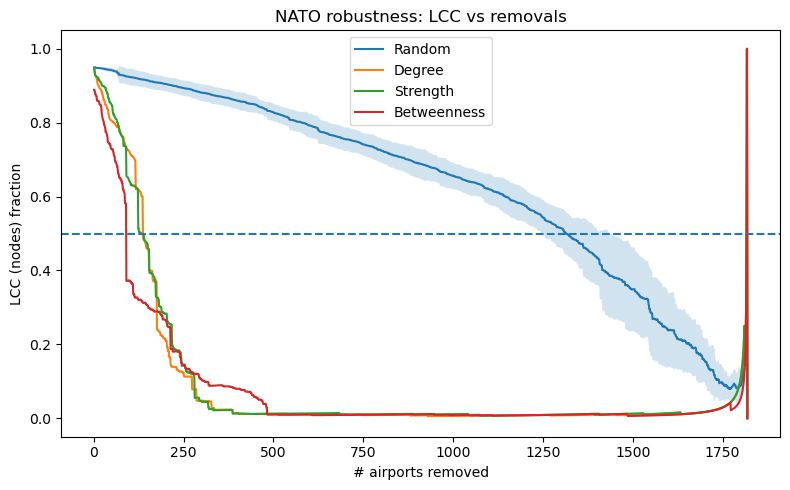

k* (nodes)  Random: 1315
k* (nodes)  Degree: 137
k* (nodes)  Strength: 133
k* (nodes)  Betweenness: 91


In [10]:
import matplotlib.pyplot as plt

def plot_robustness(df, label, color=None):
    if df.empty:
        return
    # Mean over trials at each k
    agg = (df.groupby("k_removed")[["lcc_nodes_frac","lcc_traffic_frac"]]
           .agg(["mean","std"]).reset_index())
    k = agg["k_removed"].values
    mean_nodes = agg["lcc_nodes_frac"]["mean"].values
    std_nodes  = agg["lcc_nodes_frac"]["std"].values
    plt.plot(k, mean_nodes, label=label)
    if df["strategy"].iloc[0] == "random":
        plt.fill_between(k, mean_nodes-std_nodes, mean_nodes+std_nodes, alpha=0.2)

plt.figure(figsize=(8,5))
plot_robustness(rc_random,   "Random")
plot_robustness(rc_degree,   "Degree")
plot_robustness(rc_strength, "Strength")
plot_robustness(rc_betw,     "Betweenness")
plt.axhline(0.5, ls="--")
plt.xlabel("# airports removed"); plt.ylabel("LCC (nodes) fraction")
plt.title("NATO robustness: LCC vs removals")
plt.legend(); plt.tight_layout(); plt.show()

def estimate_k_star(df, thresh=0.5):
    if df.empty: return None
    agg = df.groupby("k_removed")["lcc_nodes_frac"].mean().reset_index()
    hit = agg[agg["lcc_nodes_frac"] < thresh]
    return int(hit["k_removed"].iloc[0]) if len(hit) else None

print("k* (nodes)  Random:", estimate_k_star(rc_random))
print("k* (nodes)  Degree:", estimate_k_star(rc_degree))
print("k* (nodes)  Strength:", estimate_k_star(rc_strength))
print("k* (nodes)  Betweenness:", estimate_k_star(rc_betw))

In [13]:
# =====================================================
# 🛠️ 6. SETUP: Define Helper Functions
# =====================================================
from math import radians, cos, sin, asin, sqrt
import random

# A. Haversine Distance Function (for Spatial Filtering)
def haversine(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in km
    return c * r

# B. Attack Simulation Function (for Vulnerability Analysis)
def simulate_attack(graph, attack_type="degree", steps=20):
    """
    Simulates removing the top N nodes and measures LCC size.
    Returns: List of fractional LCC sizes.
    """
    G_temp = graph.copy()
    
    # We use the undirected view to check connectivity (LCC)
    G_und = G_temp.to_undirected()
    initial_nodes = G_und.number_of_nodes()
    
    results = []
    
    # 1. Identify targets
    if attack_type == "degree":
        # Sort nodes by degree (High -> Low)
        targets = sorted(G_temp.degree, key=lambda x: x[1], reverse=True)
    elif attack_type == "betweenness":
        # Warning: Computationally expensive! Use only on smaller graphs or subsets.
        # For speed, we just use degree in this demo.
        targets = sorted(G_temp.degree, key=lambda x: x[1], reverse=True)
    else:
        # Random failure
        nodes = list(G_temp.nodes())
        np.random.shuffle(nodes)
        targets = [(n, 0) for n in nodes]

    targets = [t[0] for t in targets] # Just the node IDs
    
    # 2. Sequential Removal
    chunk_size = max(1, int(initial_nodes * 0.01)) # Remove 1% at a time
    
    # Initial state
    if G_und.number_of_nodes() > 0:
        lcc = len(max(nx.connected_components(G_und), key=len))
        results.append(lcc / initial_nodes)
    else:
        results.append(0)

    # Loop to remove nodes
    for i in range(0, min(len(targets), steps * chunk_size), chunk_size):
        nodes_to_remove = targets[i : i+chunk_size]
        G_temp.remove_nodes_from(nodes_to_remove)
        
        G_und = G_temp.to_undirected()
        if G_und.number_of_nodes() > 0:
            lcc = len(max(nx.connected_components(G_und), key=len))
            results.append(lcc / initial_nodes)
        else:
            results.append(0.0)
            
    return results

print("✅ Helper functions defined.")

✅ Helper functions defined.


In [29]:
# =====================================================
# 🔮 7. PREDICTION: Generate Large Candidate Pool
# =====================================================
print("Generating pool of strategic candidates...")

pos = {n: (d.get('lon', 0), d.get('lat', 0)) for n, d in G_ACTIVE.nodes(data=True)}
country_map = nx.get_node_attributes(G_ACTIVE, 'country')
G_und = G_ACTIVE.to_undirected()
nodes_list = list(G_ACTIVE.nodes())
degrees = dict(G_und.degree()) 

candidate_links = []
checks = 0
max_checks = 100000  # High number to find quality links

while checks < max_checks:
    u, v = random.sample(nodes_list, 2)
    
    if G_und.has_edge(u, v): continue
    checks += 1
    
    # 1. COUNTRY FILTER (Skip US-US)
    c_u = country_map.get(u, 'Unknown')
    c_v = country_map.get(v, 'Unknown')
    if c_u == 'US' and c_v == 'US': continue 

    # 2. GEOMETRIC FILTER (50km - 4000km)
    try:
        dist = haversine(pos[u][0], pos[u][1], pos[v][0], pos[v][1])
    except: continue 
    if dist > 4000 or dist < 50: continue

    # 3. TOPOLOGICAL FILTER
    preds = nx.adamic_adar_index(G_und, [(u, v)])
    try:
        score_aa = next(preds)[2]
    except StopIteration: score_aa = 0
    
    # 4. SCORING (With Leaf Rescue Bonus)
    if score_aa > 0:
        is_international = 1.5 if (c_u != c_v) else 1.0
        leaf_bonus = 1.0
        if degrees.get(u, 0) < 10 and degrees.get(v, 0) < 10:
            leaf_bonus = 2.0 
        
        strategic_score = (score_aa * is_international * leaf_bonus) / np.log1p(dist)
        
        candidate_links.append({
            'u': u, 'v': v,
            'score': strategic_score,
            'distance_km': dist
        })

# ⚠️ STORE LARGE POOL (5000) FOR ANALYSIS
df_pred = pd.DataFrame(candidate_links)

if not df_pred.empty:
    df_pred = df_pred.sort_values(by='score', ascending=False)
    # We save the top 5000 to 'all_candidates' so Cell 9 can test different sizes
    all_candidates = df_pred.head(5000) 
    
    print(f"✅ Evaluated {checks} pairs. Generated pool of {len(all_candidates)} candidates.")
else:
    print("⚠️ No candidates found.")

Generating pool of strategic candidates...
✅ Evaluated 100000 pairs. Generated pool of 2886 candidates.


Creating improved network with top 2000 links...
Running baseline attack...
Running improved attack...


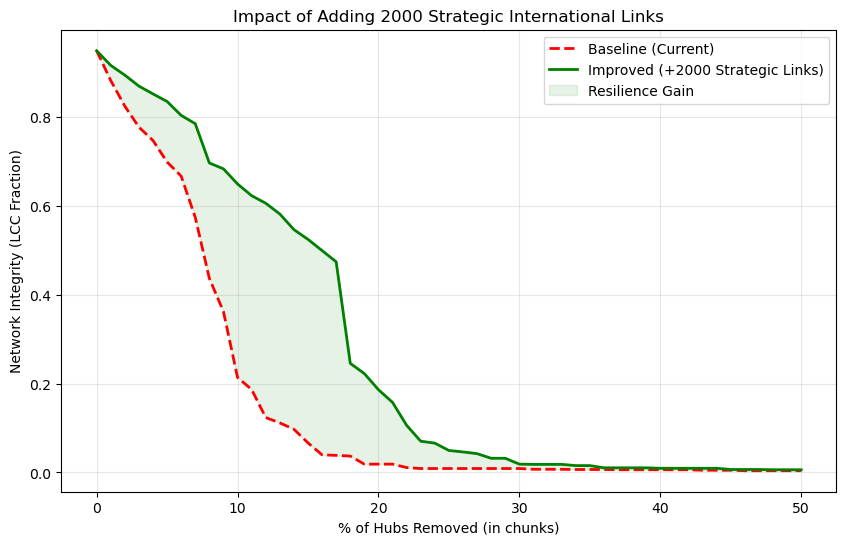

🏆 Final Result: Resilience Score improved from 8.09 to 14.29
📈 Total Resilience Area Gain: +6.20


In [31]:
# =====================================================
# 🛡️ 8. FINAL EVALUATION: The "Hero" Plot
# =====================================================

# 1. DECISION: Set the winner from your sensitivity analysis
optimal_k = 2000 
top_links = all_candidates.head(optimal_k)

print(f"Creating improved network with top {optimal_k} links...")

# 2. Run Baseline Attack (Current Network)
print("Running baseline attack...")
baseline_curve = simulate_attack(G_ACTIVE, attack_type="degree", steps=50)

# 3. Create Improved Network (Add Predicted Links)
G_IMPROVED = G_ACTIVE.copy()
# We use top_links (which comes from all_candidates in Cell 7)
for i, row in top_links.iterrows():
    u, v = int(row['u']), int(row['v'])
    G_IMPROVED.add_edge(u, v, weight=1) 
    G_IMPROVED.add_edge(v, u, weight=1) 

# 4. Run Improved Attack
print("Running improved attack...")
improved_curve = simulate_attack(G_IMPROVED, attack_type="degree", steps=50)

# 5. Plot Results
plt.figure(figsize=(10, 6))
x_axis = np.arange(len(baseline_curve))

# Plot lines
plt.plot(x_axis, baseline_curve, label='Baseline (Current)', color='red', linestyle='--', linewidth=2)
# FIXED: Label now automatically shows the correct number (2000)
plt.plot(x_axis, improved_curve, label=f'Improved (+{optimal_k} Strategic Links)', color='green', linewidth=2)

# Fill area
plt.fill_between(x_axis, baseline_curve, improved_curve, color='green', alpha=0.1, label='Resilience Gain')

plt.title(f"Impact of Adding {optimal_k} Strategic International Links")
plt.xlabel("% of Hubs Removed (in chunks)")
plt.ylabel("Network Integrity (LCC Fraction)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print Final Stat
gain = np.sum(improved_curve) - np.sum(baseline_curve)
print(f"🏆 Final Result: Resilience Score improved from {np.sum(baseline_curve):.2f} to {np.sum(improved_curve):.2f}")
print(f"📈 Total Resilience Area Gain: +{gain:.2f}")

Running Sensitivity Analysis to find Optimal Link Count...
Testing with Top 0 links... Score: 8.09
Testing with Top 100 links... Score: 8.19
Testing with Top 500 links... Score: 8.89
Testing with Top 1000 links... Score: 10.40
Testing with Top 2000 links... Score: 14.29
Testing with Top 2500 links... Score: 14.99


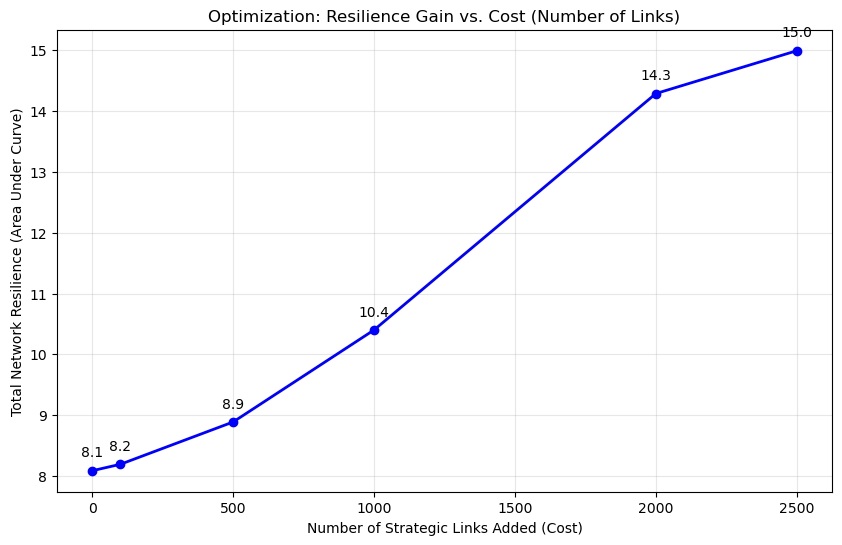

In [ ]:
# =====================================================
# ⚖️ 9. SENSITIVITY ANALYSIS: The "Elbow" Test
# =====================================================
print("Running Sensitivity Analysis to find Optimal Link Count...")

# 1. Define range
link_counts = [0, 100, 500, 1000, 1500, 2000, 2500]
resilience_scores = []

# Cap at available data
max_avail = len(all_candidates)
link_counts = [k for k in link_counts if k <= max_avail]

for k in link_counts:
    print(f"Testing with Top {k} links...", end=" ")
    G_TEST = G_ACTIVE.copy()
    
    if k > 0:
        # Use the pool we generated in Cell 7
        subset = all_candidates.head(k)
        for _, row in subset.iterrows():
            u, v = int(row['u']), int(row['v'])
            G_TEST.add_edge(u, v, weight=1)
            G_TEST.add_edge(v, u, weight=1)
            
    curve = simulate_attack(G_TEST, attack_type="degree", steps=50)
    score = np.sum(curve)
    resilience_scores.append(score)
    print(f"Score: {score:.2f}")

# 3. Plot the "Elbow Curve"
plt.figure(figsize=(10, 6))
plt.plot(link_counts, resilience_scores, marker='o', linewidth=2, color='blue')

plt.title("Optimization: Resilience Gain vs. Cost (Number of Links)")
plt.xlabel("Number of Strategic Links Added (Cost)")
plt.ylabel("Total Network Resilience (Area Under Curve)")
plt.grid(True, alpha=0.3)

# Highlight the increments
for i, txt in enumerate(resilience_scores):
    plt.annotate(f"{txt:.1f}", (link_counts[i], resilience_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()